In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# cell for fiesta.mp4
video_path = '/content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/fiesta.mp4'
YOLO_output_path = '/content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/YOLO_output'
proj_name = 'Seg_fiesta'

In [ ]:
# cell for tecnun.mp4
video_path = '/content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/tecnun.mp4'
YOLO_output_path = '/content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/YOLO_output'
proj_name = 'Seg_tecnun'

In [ ]:
# cell for dividing the video into frames

os.makedirs(YOLO_output_path, exist_ok=True)
os.makedirs(YOLO_output_path+'/orig_frames', exist_ok=True)

# Open the video
cap = cv2.VideoCapture(video_path)

# Check if video opened successfully
if not cap.isOpened():
    print("Error opening video")

frame_id = 0

while True:
    # Read the video frame by frame
    ret, frame = cap.read()

    # If the frame was read correctly ret is True
    if not ret:
        break

    # Save the current frame as an image
    cv2.imwrite(YOLO_output_path+'/orig_frames/'+'frame_{}.png'.format(frame_id), frame)
    frame_id += 1

# Close the video after reading
cap.release()

In [ ]:
images_names = os.listdir(YOLO_output_path+'/orig_frames/')
print('Total images: ', len(images_names))

Total images:  800


## YOLO SECTION

### Imports

In [ ]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 654.0/654.0 kB 6.6 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import torch
print(torch.cuda.is_available())
import gc

True


### Model selection

In [ ]:
model = YOLO('yolov8n-seg.pt') # select the model you want to use from the library of YOLO models available (https://github.com/ultralytics/ultralytics)

100%|██████████| 6.73M/6.73M [00:00<00:00, 48.8MB/s]


In [ ]:
# make predictions on a video file
# Select stream = True to use the memory efficiently as every frame is processed separately
# In other case the model load all the frames and the memory can colapse in long videos.
# Select also save = True to create the video output once you execute the plot method on the results object
results = model.predict(source=video_path, stream=True, save=False, project=YOLO_output_path, name=proj_name)


video 1/1 (1/800) /content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/tecnun.mp4: 384x640 2 cars, 1 truck, 4 potted plants, 31.9ms
video 1/1 (2/800) /content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/tecnun.mp4: 384x640 2 cars, 1 truck, 4 potted plants, 21.2ms
video 1/1 (3/800) /content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/tecnun.mp4: 384x640 2 cars, 1 truck, 4 potted plants, 11.3ms
video 1/1 (4/800) /content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/tecnun.mp4: 384x640 2 cars, 1 truck, 5 potted plants, 10.1ms
video 1/1 (5/800) /content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/tecnun.mp4: 384x640 2 cars, 1 truck, 6 potted plants, 9.8ms
{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 

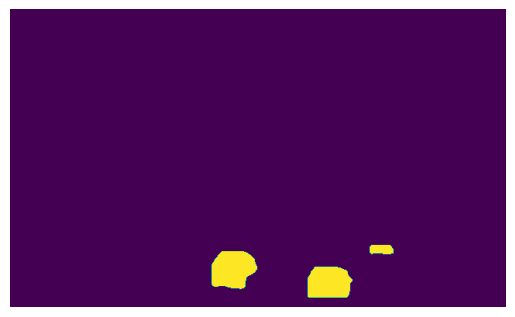

In [ ]:
# this cell and the next one can not be run in the same execution
# results is a generator and it is removed in the first use
# that's why cell with the predict is repeated

frame=5
cont=0
for result in results:

    if cont==frame:
      print(result.names)
      # get array results
      masks = result.masks.data
      boxes = result.boxes.data
      # extract classes
      clss = boxes[:, 5]
      # get indices of results where class is 0 or 2 (person or car in COCO)
      indices = torch.where(clss == 2)
      # use these indices to extract the relevant masks
      masks = masks[indices]
      # scale for visualizing results
      mask = torch.any(masks, dim=0).int() * 255

      plt.imshow(mask.cpu().numpy())
      plt.axis('off')
      plt.show()
      break

    cont+=1


In [ ]:
# make predictions on a video file
# Select stream = True to use the memory efficiently as every frame is processed separately
# In other case the model load all the frames and the memory can colapse in long videos.
# Select also save = True to create the video output once you execute the plot method on the results object
results = model.predict(source=video_path, stream=True, save=True, project=YOLO_output_path, name=proj_name)

In [ ]:
# move through results object and plot the inference, as save is set to True, the final video will be created and stored
for result in results:
    result.plot()


video 1/1 (1/800) /content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/tecnun.mp4: 384x640 2 cars, 1 truck, 4 potted plants, 10.0ms
video 1/1 (2/800) /content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/tecnun.mp4: 384x640 2 cars, 1 truck, 4 potted plants, 10.1ms
video 1/1 (3/800) /content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/tecnun.mp4: 384x640 2 cars, 1 truck, 4 potted plants, 13.1ms
video 1/1 (4/800) /content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/tecnun.mp4: 384x640 2 cars, 1 truck, 5 potted plants, 15.6ms
video 1/1 (5/800) /content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/tecnun.mp4: 384x640 2 cars, 1 truck, 6 potted plants, 11.1ms
video 1/1 (6/800) /content/drive/MyDrive/Colab Notebooks/Computer Vision course/DL/04 - Segmentation-Tecnun/tecnun.mp4: 384x640 3 cars, 1 truck, 5 potted 

# Macro-lab (no coding)

- Compute metrics only with classification boxes/seg
- Use metrics we saw in classification chapter

- Confussion matrix will only have the following classes:
  - 0: 'person'
  - 1: 'bicycle
  - 2: 'car' (incluye furgonetas)
  - 3: 'motorcycle'
  - 7: 'truck'
  - 9: 'traffic light'
  - 11: 'stop sign' (incluye cualquier tipo de señal)
  - 12: 'parking meter'
  - 58: 'potted plant'

EACH STUDENT HAS 10 FRAMES:

- Arenas Prado	César Fernando: 1-10
- Bober Irizar	Jan Krzysztof: 101-110
- Etxebeste Arroyo	Iker: 201-210
- Imaz Dravasa	Jon: 301-310
- Masó López	Oscar: 401-410
- Russo del Río	Pablo: 501-510
- Temiño Álvarez	Marta: 601-610
- Vera Aguinaga	Jorge: 701-710

Write a doc file with the following info:
- For each frame, put snapshot of frame-orig and frame-processed
- For each frame, build the confussion matrix
- For each frame, compute class metrics
- Compute class metrics for all your frames (avg)

###Send an email with the doc file to the professor.